In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import subprocess
from scipy.stats import chisquare
import os
import glob

# import scipy.stats as stats

In [3]:
%load_ext autoreload

%autoreload 2
import pandas as pd
import numpy as np
%aimport Variant_analysis_helper_functions


#import protfasta
import os

# Running enrichment analysis scripts

In [16]:
! python3 ../scripts/get_full_mutations.py --variants_filename SFARI_TF_de_novo_variants_gpf.bed  --variants_folder /Users/sanjanakotha/Desktop/Staller_Lab/SFARI/soto_analysis/raw_files/ --sort_TFs true --sort_variants true

Sorting TF bed files.
100%|██████████████████████████████████████| 1561/1561 [00:05<00:00, 301.81it/s]
Done sorting the TF bed files!
Sorting variants. at /Users/sanjanakotha/Desktop/Staller_Lab/SFARI/soto_analysis/raw_files/SFARI_TF_de_novo_variants_gpf.bed
Done sorting variants!
/Users/sanjanakotha/Desktop/Staller_Lab/SFARI/soto_analysis/raw_files/sorted/SFARI_TF_de_novo_variants_gpf.bed
Starting intersecting CDS bed files and variants.
Intersecting: 100%|████████████████████████| 1561/1561 [00:01<00:00, 950.98it/s]
Done intersecting.


In [20]:
! python3 ../scripts/classify_mutations.py --variants_filename SFARI_TF_de_novo_variants_gpf.bed

Intersecting: 100%|██████████████████████| 1559/1559 [00:00<00:00, 14755.05it/s]


In [21]:
! python3 ../scripts/get_mutations_domains_snv_classified.py --domain none --variants_filename SFARI_TF_de_novo_variants_gpf.bed

Processing: 100%|██████████████████████████| 1558/1558 [00:01<00:00, 815.95it/s]


---
# Building table

In [11]:
# Only keep SFARI TFs
all_TFs = pd.read_csv("../outputs/TFs_table_proteins.txt", sep = "\t")
TF_ENSTs = set(all_TFs["ENST"])
TF_ENSTs

{'ENST00000056233',
 'ENST00000239243',
 'ENST00000241001',
 'ENST00000246672',
 'ENST00000250916',
 'ENST00000262238',
 'ENST00000262518',
 'ENST00000264637',
 'ENST00000265340',
 'ENST00000282549',
 'ENST00000288319',
 'ENST00000303329',
 'ENST00000309446',
 'ENST00000312233',
 'ENST00000315869',
 'ENST00000317216',
 'ENST00000318003',
 'ENST00000331340',
 'ENST00000335670',
 'ENST00000339562',
 'ENST00000341099',
 'ENST00000342988',
 'ENST00000348066',
 'ENST00000348332',
 'ENST00000355311',
 'ENST00000355995',
 'ENST00000356073',
 'ENST00000358127',
 'ENST00000359486',
 'ENST00000367265',
 'ENST00000372583',
 'ENST00000373036',
 'ENST00000373294',
 'ENST00000377022',
 'ENST00000377142',
 'ENST00000379044',
 'ENST00000380013',
 'ENST00000389506',
 'ENST00000395324',
 'ENST00000403491',
 'ENST00000428368',
 'ENST00000434704',
 'ENST00000437473',
 'ENST00000561208',
 'ENST00000592199'}

In [12]:
# Only keep ENSTs which have variants in domains
ENSTs_w_vars = glob.glob("../outputs/mutations/domains_SFARI_TF_de_novo_variants_gpf_snv_classified/*")
ENSTs_w_vars = [s.split("/")[-1].split(".")[0] for s in ENSTs_w_vars]
ENSTs_w_vars

['ENST00000296096',
 'ENST00000419098',
 'ENST00000259803',
 'ENST00000698516',
 'ENST00000506184',
 'ENST00000443427',
 'ENST00000234392',
 'ENST00000675105',
 'ENST00000295206',
 'ENST00000361387',
 'ENST00000530393',
 'ENST00000434687',
 'ENST00000268638',
 'ENST00000474710',
 'ENST00000162391',
 'ENST00000448943',
 'ENST00000543802',
 'ENST00000400085',
 'ENST00000356073',
 'ENST00000418153',
 'ENST00000698099',
 'ENST00000399602',
 'ENST00000503201',
 'ENST00000436292',
 'ENST00000241527',
 'ENST00000321358',
 'ENST00000283921',
 'ENST00000538320',
 'ENST00000444957',
 'ENST00000360338',
 'ENST00000342833',
 'ENST00000398468',
 'ENST00000377687',
 'ENST00000358664',
 'ENST00000411995',
 'ENST00000492450',
 'ENST00000508793',
 'ENST00000369888',
 'ENST00000362063',
 'ENST00000602212',
 'ENST00000672722',
 'ENST00000302754',
 'ENST00000587539',
 'ENST00000311066',
 'ENST00000595883',
 'ENST00000241651',
 'ENST00000306268',
 'ENST00000300619',
 'ENST00000580243',
 'ENST00000393716',


In [13]:
d_domains = "../outputs/mutations/domains_SFARI_TF_de_novo_variants_gpf_snv_classified/"
files = os.listdir(d_domains)
ENST_codes = [f.replace(".bed", "") for f in files if f !='.ipynb_checkpoints']

In [14]:
# Only keep SFARI TFs
uniprotID_ENST_mapping = pd.read_csv("../../data/SFARI_TFs_with_ENST_corrected.csv")
uniprotID_ENST_mapping = uniprotID_ENST_mapping[["uniprotID", "ENST"]]
uniprotID_ENST_mapping["ENST"] = uniprotID_ENST_mapping["ENST"].str.split(".").str[0]
uniprotID_ENST_mapping_dict= dict(zip(uniprotID_ENST_mapping["ENST"], uniprotID_ENST_mapping["uniprotID"]))
uniprotID_ENST_mapping_dict['ENST00000434704'] = 'O60479'

# ENSTs to keep, SK 11/18/24
ENST_codes = set(ENST_codes) & set(uniprotID_ENST_mapping_dict.keys()) & set(TF_ENSTs) & set(ENSTs_w_vars)
len(ENST_codes)


45

In [15]:
# Only keep ENSTs with at least one var
ENST_codes_to_use = []

for ENST_code in ENST_codes:
    with open(d_domains + ENST_code + ".bed", 'r') as fp:
        lines = len(fp.readlines())
        if lines == 0:
            print(ENST_code)
        else:
            ENST_codes_to_use.append(ENST_code)

ENST00000434704
ENST00000377142
ENST00000592199
ENST00000312233
ENST00000373036
ENST00000303329
ENST00000282549
ENST00000239243
ENST00000395324
ENST00000264637
ENST00000241001
ENST00000348066


In [16]:
len(ENST_codes_to_use)

33

In [17]:
ENST_codes_to_use

['ENST00000318003',
 'ENST00000359486',
 'ENST00000342988',
 'ENST00000250916',
 'ENST00000339562',
 'ENST00000379044',
 'ENST00000262238',
 'ENST00000056233',
 'ENST00000372583',
 'ENST00000331340',
 'ENST00000317216',
 'ENST00000373294',
 'ENST00000355311',
 'ENST00000335670',
 'ENST00000356073',
 'ENST00000403491',
 'ENST00000428368',
 'ENST00000265340',
 'ENST00000355995',
 'ENST00000348332',
 'ENST00000288319',
 'ENST00000309446',
 'ENST00000358127',
 'ENST00000246672',
 'ENST00000437473',
 'ENST00000389506',
 'ENST00000315869',
 'ENST00000561208',
 'ENST00000377022',
 'ENST00000341099',
 'ENST00000367265',
 'ENST00000262518',
 'ENST00000380013']

In [18]:
ENST_codes_to_use_test = ["ENST00000380013"]

In [23]:
#slower to run
SFARI_TFs = pd.read_csv("../../data/SFARI_TFs_with_ENST.csv")

output = Variant_analysis_helper_functions.generate_df_parallel_progress(ENST_codes_to_use, -1, 1, 
                                                       domain_types = ["AD", "DBD", "RD"], print_output = True,
                                                      variant_filename = "SFARI_TF_de_novo_variants_gpf")

Processing ENST codes: 100%|██████████| 33/33 [00:02<00:00, 13.79it/s]

8 ENST00000056233
5 ENST00000339562
2 ENST00000359486
4 ENST00000250916
1 ENST00000318003
3 ENST00000342988
7 ENST00000262238
6 ENST00000379044
9 ENST00000372583
10 ENST00000331340
11 ENST00000317216
12 ENST00000373294
13 ENST00000355311
14 ENST00000335670
15 ENST00000356073
16 ENST00000403491
17 ENST00000428368
18 ENST00000265340
19 ENST00000355995
20 ENST00000348332
21 ENST00000288319
22 ENST00000309446
23 ENST00000358127
24 ENST00000246672
25 ENST00000437473
26 ENST00000389506
27 ENST00000315869
28 ENST00000561208
29 ENST00000377022
30 ENST00000341099
31 ENST00000367265
32 ENST00000262518
33 ENST00000380013


In [24]:
#slower to run

output_slow = Variant_analysis_helper_functions.generate_df(ENST_codes_to_use, uniprotID_ENST_mapping_dict, -1, 1, 
                                                       domain_types = ["AD", "DBD", "RD"], print_output = True,
                                                      variant_filename = "SFARI_TF_de_novo_variants_gpf")

1 ENST00000318003
2 ENST00000359486
3 ENST00000342988
4 ENST00000250916
5 ENST00000339562
6 ENST00000379044
7 ENST00000262238
8 ENST00000056233
9 ENST00000372583
10 ENST00000331340
11 ENST00000317216
12 ENST00000373294
13 ENST00000355311
14 ENST00000335670
15 ENST00000356073
16 ENST00000403491
17 ENST00000428368
18 ENST00000265340
19 ENST00000355995
20 ENST00000348332
21 ENST00000288319
22 ENST00000309446
23 ENST00000358127
24 ENST00000246672
25 ENST00000437473
26 ENST00000389506
27 ENST00000315869
28 ENST00000561208
29 ENST00000377022
30 ENST00000341099
31 ENST00000367265
32 ENST00000262518
33 ENST00000380013


In [25]:
# Testing parallelized- great, the output looks the same. can use parallelized version from now on.
pd.merge(output, output_slow)

,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop
0,Q9BXK1,759,1,0.001318,132,0,0.000000,219,1,0.004566,0,0,NaN
1,Q9UGU0,5883,3,0.000510,981,1,0.001019,5880,3,0.000510,0,0,NaN
2,Q6P1N0,2856,1,0.000350,117,0,0.000000,2853,1,0.000351,0,0,NaN
3,P25490,1245,3,0.002410,288,2,0.006944,294,1,0.003401,0,0,NaN
4,Q9Y4A8,2085,1,0.000480,600,0,0.000000,189,1,0.005291,0,0,NaN
5,P43354,1797,3,0.001669,318,0,0.000000,210,3,0.014286,0,0,NaN
6,Q13485,1659,3,0.001808,927,2,0.002157,306,0,0.000000,0,0,NaN
7,Q96QS3,1689,2,0.001184,273,0,0.000000,171,0,0.000000,0,0,NaN
8,Q5T1R4,7221,1,0.000138,2592,1,0.000386,282,0,0.000000,0,0,NaN
9,Q9Y458,1563,1,0.000640,240,0,0.000000,570,1,0.001754,0,0,NaN


In [26]:
output_saved = output.copy(deep = True)
output_saved

,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop
0,Q9BXK1,759,1,0.001318,132,0,0.000000,219,1,0.004566,0,0,NaN
1,Q9UGU0,5883,3,0.000510,981,1,0.001019,5880,3,0.000510,0,0,NaN
2,Q6P1N0,2856,1,0.000350,117,0,0.000000,2853,1,0.000351,0,0,NaN
3,P25490,1245,3,0.002410,288,2,0.006944,294,1,0.003401,0,0,NaN
4,Q9Y4A8,2085,1,0.000480,600,0,0.000000,189,1,0.005291,0,0,NaN
5,P43354,1797,3,0.001669,318,0,0.000000,210,3,0.014286,0,0,NaN
6,Q13485,1659,3,0.001808,927,2,0.002157,306,0,0.000000,0,0,NaN
7,Q96QS3,1689,2,0.001184,273,0,0.000000,171,0,0.000000,0,0,NaN
8,Q5T1R4,7221,1,0.000138,2592,1,0.000386,282,0,0.000000,0,0,NaN
9,Q9Y458,1563,1,0.000640,240,0,0.000000,570,1,0.001754,0,0,NaN


In [27]:
# Removing rows without ADs
output = output.dropna(subset = ["AD_missense_prop"])
output = output.reset_index(drop = True)
output

,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop
0,Q9BXK1,759,1,0.001318,132,0,0.000000,219,1,0.004566,0,0,NaN
1,Q9UGU0,5883,3,0.000510,981,1,0.001019,5880,3,0.000510,0,0,NaN
2,Q6P1N0,2856,1,0.000350,117,0,0.000000,2853,1,0.000351,0,0,NaN
3,P25490,1245,3,0.002410,288,2,0.006944,294,1,0.003401,0,0,NaN
4,Q9Y4A8,2085,1,0.000480,600,0,0.000000,189,1,0.005291,0,0,NaN
5,P43354,1797,3,0.001669,318,0,0.000000,210,3,0.014286,0,0,NaN
6,Q13485,1659,3,0.001808,927,2,0.002157,306,0,0.000000,0,0,NaN
7,Q96QS3,1689,2,0.001184,273,0,0.000000,171,0,0.000000,0,0,NaN
8,Q5T1R4,7221,1,0.000138,2592,1,0.000386,282,0,0.000000,0,0,NaN
9,Q9Y458,1563,1,0.000640,240,0,0.000000,570,1,0.001754,0,0,NaN


In [28]:
Variant_analysis_helper_functions.add_fisher_p_vals_vs_control(output, "AD")
output = pd.merge(SFARI_TFs[["gene-symbol", "uniprotID"]], output)
output

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
0,ARX,Q96QS3,1689,2,0.001184,273,0,0.000000,171,0,0.000000,0,0,NaN,1.000000
1,CASZ1,Q86V15,5280,2,0.000379,465,0,0.000000,825,0,0.000000,0,0,NaN,1.000000
2,CC2D1A,Q6P1N0,2856,1,0.000350,117,0,0.000000,2853,1,0.000351,0,0,NaN,1.000000
3,EBF3,Q9H4W6,1791,7,0.003908,240,0,0.000000,693,2,0.002886,0,0,NaN,0.603536
4,EGR3,Q06889,1164,2,0.001718,606,1,0.001650,213,0,0.000000,0,0,NaN,1.000000
5,ESR2,Q92731,1593,2,0.001255,1035,2,0.001932,210,0,0.000000,0,0,NaN,0.544545
6,ERG,P11308,1440,1,0.000694,573,0,0.000000,240,0,0.000000,0,0,NaN,1.000000
7,HIVEP3,Q5T1R4,7221,1,0.000138,2592,1,0.000386,282,0,0.000000,0,0,NaN,0.358953
8,IKZF1,Q13422,1560,2,0.001282,246,2,0.008130,279,0,0.000000,0,0,NaN,0.024782
9,KDM5B,Q9UGL1,4635,14,0.003020,270,1,0.003704,255,1,0.003922,0,0,NaN,0.568923


In [29]:
output[output["TF_missense_prop"] > output["AD_missense_prop"]]

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
0,ARX,Q96QS3,1689,2,0.001184,273,0,0.000000,171,0,0.000000,0,0,NaN,1.000000
1,CASZ1,Q86V15,5280,2,0.000379,465,0,0.000000,825,0,0.000000,0,0,NaN,1.000000
2,CC2D1A,Q6P1N0,2856,1,0.000350,117,0,0.000000,2853,1,0.000351,0,0,NaN,1.000000
3,EBF3,Q9H4W6,1791,7,0.003908,240,0,0.000000,693,2,0.002886,0,0,NaN,0.603536
4,EGR3,Q06889,1164,2,0.001718,606,1,0.001650,213,0,0.000000,0,0,NaN,1.000000
6,ERG,P11308,1440,1,0.000694,573,0,0.000000,240,0,0.000000,0,0,NaN,1.000000
10,KLF16,Q9BXK1,759,1,0.001318,132,0,0.000000,219,1,0.004566,0,0,NaN,1.000000
11,KLF7,O75840,909,2,0.002200,300,0,0.000000,219,0,0.000000,0,0,NaN,1.000000
12,KMT2A,Q03164,11910,5,0.000420,420,0,0.000000,144,0,0.000000,0,0,NaN,1.000000
13,MEF2C,Q06413,1422,5,0.003516,1161,1,0.000861,144,3,0.020833,0,0,NaN,0.004761


In [30]:
output[output["DBD_missense_prop"] > output["AD_missense_prop"]]

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
2,CC2D1A,Q6P1N0,2856,1,0.000350,117,0,0.000000,2853,1,0.000351,0,0,NaN,1.000000
3,EBF3,Q9H4W6,1791,7,0.003908,240,0,0.000000,693,2,0.002886,0,0,NaN,0.603536
9,KDM5B,Q9UGL1,4635,14,0.003020,270,1,0.003704,255,1,0.003922,0,0,NaN,0.568923
10,KLF16,Q9BXK1,759,1,0.001318,132,0,0.000000,219,1,0.004566,0,0,NaN,1.000000
13,MEF2C,Q06413,1422,5,0.003516,1161,1,0.000861,144,3,0.020833,0,0,NaN,0.004761
14,MEIS2,O14770,1434,2,0.001395,414,1,0.002415,174,1,0.005747,0,0,NaN,0.494200
15,MYT1L,Q9UL68,3561,7,0.001966,822,1,0.001217,552,4,0.007246,0,0,NaN,1.000000
17,NFE2L3,Q9Y4A8,2085,1,0.000480,600,0,0.000000,189,1,0.005291,0,0,NaN,1.000000
20,NR4A2,P43354,1797,3,0.001669,318,0,0.000000,210,3,0.014286,0,0,NaN,1.000000
21,PAX5,Q02548,1176,1,0.000850,165,0,0.000000,375,1,0.002667,0,0,NaN,1.000000


---
# AD vs DBD

In [31]:
contains_DBD = output[output["DBD_cds_length"] != 0]
contains_DBD = contains_DBD.reset_index(drop = True)
contains_DBD

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
0,ARX,Q96QS3,1689,2,0.001184,273,0,0.000000,171,0,0.000000,0,0,NaN,1.000000
1,CASZ1,Q86V15,5280,2,0.000379,465,0,0.000000,825,0,0.000000,0,0,NaN,1.000000
2,CC2D1A,Q6P1N0,2856,1,0.000350,117,0,0.000000,2853,1,0.000351,0,0,NaN,1.000000
3,EBF3,Q9H4W6,1791,7,0.003908,240,0,0.000000,693,2,0.002886,0,0,NaN,0.603536
4,EGR3,Q06889,1164,2,0.001718,606,1,0.001650,213,0,0.000000,0,0,NaN,1.000000
5,ESR2,Q92731,1593,2,0.001255,1035,2,0.001932,210,0,0.000000,0,0,NaN,0.544545
6,ERG,P11308,1440,1,0.000694,573,0,0.000000,240,0,0.000000,0,0,NaN,1.000000
7,HIVEP3,Q5T1R4,7221,1,0.000138,2592,1,0.000386,282,0,0.000000,0,0,NaN,0.358953
8,IKZF1,Q13422,1560,2,0.001282,246,2,0.008130,279,0,0.000000,0,0,NaN,0.024782
9,KDM5B,Q9UGL1,4635,14,0.003020,270,1,0.003704,255,1,0.003922,0,0,NaN,0.568923


In [32]:
len(contains_DBD)

33

In [33]:
Variant_analysis_helper_functions.add_fisher_p_vals_vs_control(contains_DBD, "AD", "DBD")

In [34]:
contains_DBD

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals,ADvsDBD_fisher_exact_p_vals
0,ARX,Q96QS3,1689,2,0.001184,273,0,0.000000,171,0,0.000000,0,0,NaN,1.000000,1.000000
1,CASZ1,Q86V15,5280,2,0.000379,465,0,0.000000,825,0,0.000000,0,0,NaN,1.000000,1.000000
2,CC2D1A,Q6P1N0,2856,1,0.000350,117,0,0.000000,2853,1,0.000351,0,0,NaN,1.000000,1.000000
3,EBF3,Q9H4W6,1791,7,0.003908,240,0,0.000000,693,2,0.002886,0,0,NaN,0.603536,1.000000
4,EGR3,Q06889,1164,2,0.001718,606,1,0.001650,213,0,0.000000,0,0,NaN,1.000000,1.000000
5,ESR2,Q92731,1593,2,0.001255,1035,2,0.001932,210,0,0.000000,0,0,NaN,0.544545,1.000000
6,ERG,P11308,1440,1,0.000694,573,0,0.000000,240,0,0.000000,0,0,NaN,1.000000,1.000000
7,HIVEP3,Q5T1R4,7221,1,0.000138,2592,1,0.000386,282,0,0.000000,0,0,NaN,0.358953,1.000000
8,IKZF1,Q13422,1560,2,0.001282,246,2,0.008130,279,0,0.000000,0,0,NaN,0.024782,0.219084
9,KDM5B,Q9UGL1,4635,14,0.003020,270,1,0.003704,255,1,0.003922,0,0,NaN,0.568923,1.000000


In [35]:
contains_DBD_sig = Variant_analysis_helper_functions.return_bh_sig(contains_DBD, "ADvsDBD_fisher_exact_p_vals", 0.1)
contains_DBD_sig

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals,ADvsDBD_fisher_exact_p_vals


In [36]:
contains_DBD_sig.sort_values(by = "ADvsDBD_fisher_exact_p_vals")

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals,ADvsDBD_fisher_exact_p_vals


In [37]:
contains_DBD_sig.sort_values(by = "ADvsDBD_fisher_exact_p_vals")[["gene-symbol", "uniprotID", "AD_missense_prop", "DBD_missense_prop", "TF_missense_prop", "ADvsDBD_fisher_exact_p_vals"]]

,gene-symbol,uniprotID,AD_missense_prop,DBD_missense_prop,TF_missense_prop,ADvsDBD_fisher_exact_p_vals


In [38]:
contains_DBD_sig[contains_DBD_sig["AD_missense_prop"] < contains_DBD_sig["DBD_missense_prop"]]

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals,ADvsDBD_fisher_exact_p_vals


In [39]:
contains_DBD_sig[contains_DBD_sig["AD_missense_prop"] < contains_DBD_sig["TF_missense_prop"]]

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals,ADvsDBD_fisher_exact_p_vals


In [40]:
for i in contains_DBD_sig["gene-symbol"].sort_values():
    print(i)

--- 
# AD vs TF

In [41]:
decisions = Variant_analysis_helper_functions.benjamini_hochberg(output["ADvsTF_fisher_exact_p_vals"], 0.1)
sig_output = output[decisions]
sig_output

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals


In [42]:
sig_output.sort_values(by = "ADvsTF_fisher_exact_p_vals")

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals


In [43]:
sig_output[sig_output["AD_missense_prop"] < sig_output["TF_missense_prop"]]

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals


# Visual

In [44]:
output

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
0,ARX,Q96QS3,1689,2,0.001184,273,0,0.000000,171,0,0.000000,0,0,NaN,1.000000
1,CASZ1,Q86V15,5280,2,0.000379,465,0,0.000000,825,0,0.000000,0,0,NaN,1.000000
2,CC2D1A,Q6P1N0,2856,1,0.000350,117,0,0.000000,2853,1,0.000351,0,0,NaN,1.000000
3,EBF3,Q9H4W6,1791,7,0.003908,240,0,0.000000,693,2,0.002886,0,0,NaN,0.603536
4,EGR3,Q06889,1164,2,0.001718,606,1,0.001650,213,0,0.000000,0,0,NaN,1.000000
5,ESR2,Q92731,1593,2,0.001255,1035,2,0.001932,210,0,0.000000,0,0,NaN,0.544545
6,ERG,P11308,1440,1,0.000694,573,0,0.000000,240,0,0.000000,0,0,NaN,1.000000
7,HIVEP3,Q5T1R4,7221,1,0.000138,2592,1,0.000386,282,0,0.000000,0,0,NaN,0.358953
8,IKZF1,Q13422,1560,2,0.001282,246,2,0.008130,279,0,0.000000,0,0,NaN,0.024782
9,KDM5B,Q9UGL1,4635,14,0.003020,270,1,0.003704,255,1,0.003922,0,0,NaN,0.568923


In [45]:
sum(output["TF_missense"])

111

In [46]:
sum(output["TF_cds_length"])

96144

In [47]:
sum(output["AD_missense"])

30

In [48]:
sum(output["AD_cds_length"])

24054

In [49]:
sum(output["DBD_missense"])

34

In [50]:
sum(output["DBD_cds_length"])

23028

In [51]:
from scipy.stats import chisquare

## AD vs DBD

# Observed counts
observed = [sum(output["AD_missense"]), sum(output["DBD_missense"])]  # AD, DBD
lengths = [sum(output["AD_cds_length"]), sum(output["DBD_cds_length"])]

# Expected counts under uniform distribution
expected = sum(observed) * np.array(lengths) / sum(lengths)

# Perform chi-squared test
chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

print("Chi-squared statistic:", chi2_stat)
print("p-value:", p_value)

Chi-squared statistic: 0.45494257660363197
p-value: 0.49999710088484894


In [52]:
lengths

[24054, 23028]

In [53]:
from scipy.stats import chisquare

## AD vs TF

# Observed counts
observed = [sum(output["AD_missense"]), sum(output["TF_missense"]) - sum(output["AD_missense"])]  # AD, TF
lengths = [sum(output["AD_cds_length"]), sum(output["TF_cds_length"]) - sum(output["AD_cds_length"])]

# Expected counts under uniform distribution
expected = sum(observed) * np.array(lengths) / sum(lengths)

# Perform chi-squared test
chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

print("Chi-squared statistic:", chi2_stat)
print("p-value:", p_value)

Chi-squared statistic: 0.23865163085456764
p-value: 0.6251816785412136


In [55]:
# Enrichment for non-gnomad variants?

In [56]:
de_novo_vars = pd.read_csv("../raw_files/SFARI_TF_de_novo_variants_gpf.bed", header = None,sep = "\t")
de_novo_vars.columns = ['CHROM', 'start', 'POS', 'REF', 'ALT', 'af']
de_novo_vars

,CHROM,start,POS,REF,ALT,af
0,1,61352563,61352564,C,T,0
1,2,1917306,1917307,A,G,0
2,2,156329363,156329364,A,G,0
3,1,61352563,61352564,C,T,0
4,4,105234730,105234731,G,T,0
...,...,...,...,...,...,...
112,18,55228884,55228885,G,A,0
113,18,55228993,55228994,G,A,0
114,21,38445460,38445461,G,C,0
115,22,42213188,42213189,C,T,0


In [57]:
gnomad_vars = pd.read_csv("../raw_files/gnomad_missense_snps.bed", sep="\t", header=None)
gnomad_vars.columns = ['CHROM', 'start', 'POS', 'REF', 'ALT', 'af']
gnomad_vars

,CHROM,start,POS,REF,ALT,af
0,2,207081140,207081141,T,C,3.216086e-06
1,2,207081144,207081145,G,C,7.777610e-07
2,2,207081145,207081146,C,G,7.714145e-07
3,2,207081146,207081147,C,T,1.529487e-06
4,2,207081147,207081148,C,T,5.777024e-06
...,...,...,...,...,...,...
107567,19,13094705,13094706,G,A,7.334088e-07
107568,19,13094708,13094709,G,T,1.997268e-06
107569,19,13094710,13094711,A,G,1.250769e-06
107570,19,13094717,13094718,A,G,3.763805e-05


In [58]:
de_novo_gnomad_overlap = pd.merge(de_novo_vars, gnomad_vars, on = ['CHROM', 'start', 'POS', 'REF', 'ALT'])
display(de_novo_gnomad_overlap.head())
print(len(de_novo_gnomad_overlap))


,CHROM,start,POS,REF,ALT,af_x,af_y
0,1,61352563,61352564,C,T,0,3.732323e-06
1,1,61352563,61352564,C,T,0,3.732323e-06
2,9,37033985,37033986,C,G,0,6.850882e-07
3,10,129840881,129840882,C,G,0,1.591090e-06
4,16,30724602,30724603,A,T,0,6.840441e-07


55


In [59]:
de_novo_no_overlap = de_novo_vars[~de_novo_vars.set_index(['CHROM', 'start', 'POS', 'REF', 'ALT']).index.isin(de_novo_gnomad_overlap.set_index(['CHROM', 'start', 'POS', 'REF', 'ALT']).index)]
display(de_novo_no_overlap.head())
print(len(de_novo_no_overlap))

,CHROM,start,POS,REF,ALT,af
1,2,1917306,1917307,A,G,0
2,2,156329363,156329364,A,G,0
4,4,105234730,105234731,G,T,0
12,19,1854681,1854682,C,G,0
16,5,174729413,174729414,C,T,0


62


In [60]:
# De novo in ADs
de_novo_variants_domains = glob.glob("../outputs/mutations/domains_SFARI_TF_de_novo_variants_gpf_snv_classified/*")
domain_dfs = [pd.read_csv(file, sep="\t", header=None) for file in de_novo_variants_domains if sum(1 for line in open(file)) > 0]
domain_df = pd.concat(domain_dfs)
AD_de_novos = domain_df[domain_df[3] == "AD"]
AD_de_novos = AD_de_novos.rename(columns = {0: 'CHROM', 1: 'start', 2: 'POS', 16: 'REF', 17: 'ALT'})
AD_de_novos[['CHROM', 'start', 'POS', 'REF', 'ALT']]

,CHROM,start,POS,REF,ALT
0,17,40097201,40097202,T,C
0,8,22692853,22692854,T,C
3,22,42214836,42214837,T,C
0,X,49030201,49030202,C,A
0,5,135028999,135029000,G,A
1,5,135028999,135029000,G,A
1,15,36892299,36892300,G,C
1,14,100277466,100277467,G,A
2,14,100277489,100277490,G,A
4,2,1922902,1922903,A,G


In [61]:
# One of 34 DBD variants in SFARI TFs overlaps a gnomad variant
DBD_de_novos = domain_df[domain_df[3] == "DBD"]
DBD_de_novos = DBD_de_novos.rename(columns = {0: 'CHROM', 1: 'start', 2: 'POS', 16: 'REF', 17: 'ALT'})
DBD_de_novos

,CHROM,start,POS,3,4,5,6,7,8,9,...,12,13,14,15,REF,ALT,18,19,20,21
0,18,55228884,55228885,DBD,NaN,.,-1,ENST00000356073,18,55228884,...,-1,18,55228884,55228885,G,A,0,A,V,No-Syn
1,18,55228986,55228987,DBD,NaN,.,-1,ENST00000356073,18,55228986,...,-1,18,55228986,55228987,C,T,0,R,Q,No-Syn
2,18,55228993,55228994,DBD,NaN,.,-1,ENST00000356073,18,55228993,...,-1,18,55228993,55228994,G,A,0,R,C,No-Syn
0,7,26185582,26185583,DBD,NaN,.,1,ENST00000056233,7,26185582,...,1,7,26185582,26185583,A,G,0,K,E,No-Syn
0,22,42212529,42212530,DBD,NaN,.,-1,ENST00000359486,22,42212529,...,-1,22,42212529,42212530,C,T,0,G,R,No-Syn
1,22,42213188,42213189,DBD,NaN,.,-1,ENST00000359486,22,42213188,...,-1,22,42213188,42213189,C,T,0,R,H,No-Syn
2,22,42214836,42214837,DBD,NaN,.,-1,ENST00000359486,22,42214836,...,-1,22,42214836,42214837,T,C,0,T,A,No-Syn
0,15,36950344,36950345,DBD,NaN,.,-1,ENST00000561208,15,36950344,...,-1,15,36950344,36950345,G,A,0,T,I,No-Syn
0,2,156329363,156329364,DBD,NaN,.,-1,ENST00000339562,2,156329363,...,-1,2,156329363,156329364,A,G,0,Y,H,No-Syn
1,2,156329363,156329364,DBD,NaN,.,-1,ENST00000339562,2,156329363,...,-1,2,156329363,156329364,A,G,0,Y,H,No-Syn


In [62]:
de_novo_vars["CHROM"] = de_novo_vars["CHROM"].astype(str)
de_novo_no_overlap["CHROM"] = de_novo_no_overlap["CHROM"].astype(str)
AD_de_novos["CHROM"] = AD_de_novos["CHROM"].astype(str)
DBD_de_novos["CHROM"] = DBD_de_novos["CHROM"].astype(str)


/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_64742/2602165110.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  de_novo_no_overlap["CHROM"] = de_novo_no_overlap["CHROM"].astype(str)


In [63]:
AD_de_novos

,CHROM,start,POS,3,4,5,6,7,8,9,...,12,13,14,15,REF,ALT,18,19,20,21
0,17,40097201,40097202,AD,NaN,.,-1,ENST00000246672,17,40097201,...,-1,17,40097201,40097202,T,C,0,D,G,No-Syn
0,8,22692853,22692854,AD,NaN,.,-1,ENST00000317216,8,22692853,...,-1,8,22692853,22692854,T,C,0,S,G,No-Syn
3,22,42214836,42214837,AD,NaN,.,-1,ENST00000359486,22,42214836,...,-1,22,42214836,42214837,T,C,0,T,A,No-Syn
0,X,49030201,49030202,AD,NaN,.,-1,ENST00000315869,X,49030201,...,-1,X,49030201,49030202,C,A,0,A,S,No-Syn
0,5,135028999,135029000,AD,NaN,.,-1,ENST00000265340,5,135028999,...,-1,5,135028999,135029000,G,A,0,L,F,No-Syn
1,5,135028999,135029000,AD,NaN,.,-1,ENST00000265340,5,135028999,...,-1,5,135028999,135029000,G,A,0,L,F,No-Syn
1,15,36892299,36892300,AD,NaN,.,-1,ENST00000561208,15,36892299,...,-1,15,36892299,36892300,G,C,0,P,R,No-Syn
1,14,100277466,100277467,AD,NaN,.,1,ENST00000262238,14,100277466,...,1,14,100277466,100277467,G,A,0,R,H,No-Syn
2,14,100277489,100277490,AD,NaN,.,1,ENST00000262238,14,100277489,...,1,14,100277489,100277490,G,A,0,G,R,No-Syn
4,2,1922902,1922903,AD,NaN,.,-1,ENST00000428368,2,1922902,...,-1,2,1922902,1922903,A,G,0,M,T,No-Syn


In [64]:
pd.merge(AD_de_novos, de_novo_no_overlap, on = ['CHROM', 'start', 'POS', 'REF', 'ALT'])

,CHROM,start,POS,3,4,5,6,7,8,9,...,13,14,15,REF,ALT,18,19,20,21,af
0,8,22692853,22692854,AD,NaN,.,-1,ENST00000317216,8,22692853,...,8,22692853,22692854,T,C,0,S,G,No-Syn,0
1,22,42214836,42214837,AD,NaN,.,-1,ENST00000359486,22,42214836,...,22,42214836,42214837,T,C,0,T,A,No-Syn,0
2,X,49030201,49030202,AD,NaN,.,-1,ENST00000315869,X,49030201,...,X,49030201,49030202,C,A,0,A,S,No-Syn,0
3,15,36892299,36892300,AD,NaN,.,-1,ENST00000561208,15,36892299,...,15,36892299,36892300,G,C,0,P,R,No-Syn,0
4,14,100277466,100277467,AD,NaN,.,1,ENST00000262238,14,100277466,...,14,100277466,100277467,G,A,0,R,H,No-Syn,0
5,14,100277489,100277490,AD,NaN,.,1,ENST00000262238,14,100277489,...,14,100277489,100277490,G,A,0,G,R,No-Syn,0
6,2,1922902,1922903,AD,NaN,.,-1,ENST00000428368,2,1922902,...,2,1922902,1922903,A,G,0,M,T,No-Syn,0
7,5,88761218,88761219,AD,NaN,.,-1,ENST00000437473,5,88761218,...,5,88761218,88761219,T,A,0,D,V,No-Syn,0
8,1,41582026,41582027,AD,NaN,.,-1,ENST00000372583,1,41582026,...,1,41582026,41582027,G,T,0,S,Y,No-Syn,0
9,1,202731925,202731926,AD,NaN,.,-1,ENST00000367265,1,202731925,...,1,202731925,202731926,G,A,0,P,L,No-Syn,0


In [65]:
pd.merge(DBD_de_novos, de_novo_no_overlap, on = ['CHROM', 'start', 'POS', 'REF', 'ALT'])

,CHROM,start,POS,3,4,5,6,7,8,9,...,13,14,15,REF,ALT,18,19,20,21,af
0,18,55228884,55228885,DBD,NaN,.,-1,ENST00000356073,18,55228884,...,18,55228884,55228885,G,A,0,A,V,No-Syn,0
1,18,55228993,55228994,DBD,NaN,.,-1,ENST00000356073,18,55228993,...,18,55228993,55228994,G,A,0,R,C,No-Syn,0
2,22,42214836,42214837,DBD,NaN,.,-1,ENST00000359486,22,42214836,...,22,42214836,42214837,T,C,0,T,A,No-Syn,0
3,15,36950344,36950345,DBD,NaN,.,-1,ENST00000561208,15,36950344,...,15,36950344,36950345,G,A,0,T,I,No-Syn,0
4,2,156329363,156329364,DBD,NaN,.,-1,ENST00000339562,2,156329363,...,2,156329363,156329364,A,G,0,Y,H,No-Syn,0
5,2,156329363,156329364,DBD,NaN,.,-1,ENST00000339562,2,156329363,...,2,156329363,156329364,A,G,0,Y,H,No-Syn,0
6,2,156329363,156329364,DBD,NaN,.,-1,ENST00000339562,2,156329363,...,2,156329363,156329364,A,G,0,Y,H,No-Syn,0
7,2,156329363,156329364,DBD,NaN,.,-1,ENST00000339562,2,156329363,...,2,156329363,156329364,A,G,0,Y,H,No-Syn,0
8,2,156329363,156329364,DBD,NaN,.,-1,ENST00000339562,2,156329363,...,2,156329363,156329364,A,G,0,Y,H,No-Syn,0
9,2,156329363,156329364,DBD,NaN,.,-1,ENST00000339562,2,156329363,...,2,156329363,156329364,A,G,0,Y,H,No-Syn,0


In [129]:

## AD vs DBD

# Observed counts
observed = [len(pd.merge(AD_de_novos, de_novo_no_overlap, on = ['CHROM', 'start', 'POS', 'REF', 'ALT'])), 
           len(pd.merge(DBD_de_novos, de_novo_no_overlap, on = ['CHROM', 'start', 'POS', 'REF', 'ALT']))]
lengths = [sum(output["AD_cds_length"]), sum(output["DBD_cds_length"])]

# Expected counts under uniform distribution
expected = sum(observed) * np.array(lengths) / sum(lengths)


print(observed)
print(expected)


# Perform chi-squared test
chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

print("Chi-squared statistic:", chi2_stat)
print("p-value:", p_value)

[14, 32]
[23.28684807 22.71315193]
Chi-squared statistic: 7.500779480933725
p-value: 0.006167229483759515


In [130]:
# AD vs TF

# Observed counts
observed = [len(pd.merge(AD_de_novos, de_novo_no_overlap, on = ['CHROM', 'start', 'POS', 'REF', 'ALT'])), 
           len(de_novo_no_overlap)]
lengths = [sum(output["AD_cds_length"]), sum(output["TF_cds_length"]) - sum(output["AD_cds_length"])]

# Expected counts under uniform distribution
expected = sum(observed) * np.array(lengths) / sum(lengths)


print(observed)
print(expected)


# Perform chi-squared test
chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

print("Chi-squared statistic:", chi2_stat)
print("p-value:", p_value)

[14, 62]
[22.68125992 53.31874008]
Chi-squared statistic: 4.736222068956911
p-value: 0.02953385914624795


In [160]:
output[["gene-symbol", "TF_missense", "TF_missense_prop",  "AD_missense", "AD_missense_prop",  "DBD_missense", "DBD_missense_prop"]].sort_values(by = "AD_missense", ascending = False)

,gene-symbol,TF_missense,TF_missense_prop,AD_missense,AD_missense_prop,DBD_missense,DBD_missense_prop
18,SRCAP,16,0.001651,6,0.001050,0,0.000000
23,TET2,7,0.001165,3,0.005882,7,0.001166
25,YY1,3,0.002410,2,0.006944,1,0.003401
3,ESR2,2,0.001255,2,0.001932,0,0.000000
5,IKZF1,2,0.001282,2,0.008130,0,0.000000
17,SMAD4,3,0.001808,2,0.002157,0,0.000000
16,PITX1,2,0.002116,2,0.013333,0,0.000000
11,NCOA1,3,0.000693,1,0.000813,0,0.000000
24,TFE3,1,0.000579,1,0.000944,0,0.000000
22,TCF7L2,2,0.001075,1,0.003333,1,0.004831


In [113]:
output

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
0,CC2D1A,Q6P1N0,2856,1,0.000350,117,0,0.000000,2853,1,0.000351,0,0,NaN,1.000000
1,EBF3,Q9H4W6,1791,7,0.003908,240,0,0.000000,693,2,0.002886,0,0,NaN,0.603536
2,EGR3,Q06889,1164,2,0.001718,606,1,0.001650,213,0,0.000000,0,0,NaN,1.000000
3,ESR2,Q92731,1593,2,0.001255,1035,2,0.001932,210,0,0.000000,0,0,NaN,0.544545
4,HIVEP3,Q5T1R4,7221,1,0.000138,2592,1,0.000386,282,0,0.000000,0,0,NaN,0.358953
5,IKZF1,Q13422,1560,2,0.001282,246,2,0.008130,279,0,0.000000,0,0,NaN,0.024782
6,KDM5B,Q9UGL1,4635,14,0.003020,270,1,0.003704,255,1,0.003922,0,0,NaN,0.568923
7,KLF16,Q9BXK1,759,1,0.001318,132,0,0.000000,219,1,0.004566,0,0,NaN,1.000000
8,MEF2C,Q06413,1422,5,0.003516,1161,1,0.000861,144,3,0.020833,0,0,NaN,0.004761
9,MEIS2,O14770,1434,2,0.001395,414,1,0.002415,174,1,0.005747,0,0,NaN,0.494200


In [118]:
len(output)

26

In [122]:
old_hits = set({
    "ARX", "CASZ1", "CAMTA2", "ERG", "HIVEP3", "IKZF1", "KDM5B", "KLF16", "KLF7",
    "MEIS2", "MTF1", "MYT1L", "NR1D1", "NKX2-2", "OTX1", "PAX5", "PAX6", "PITX1",
    "TFE3", "YY1"
}
)

In [124]:
with_denovo = set(output[output["AD_missense"] != 0]["gene-symbol"])
with_denovo

{'EGR3',
 'ESR2',
 'HIVEP3',
 'IKZF1',
 'KDM5B',
 'MEF2C',
 'MEIS2',
 'MYT1L',
 'NCOA1',
 'NR1D1',
 'PITX1',
 'SMAD4',
 'SRCAP',
 'TCF20',
 'TCF7L2',
 'TET2',
 'TFE3',
 'YY1'}

In [143]:
cc_list = {
    "NR4A2", "ERG", "PITX1", "NKX2-2", "PAX5", 
    "IKZF1", "NR4A2", "CAMTA2", "MEIS2", "NCOA1", 
    "PAX6"
}


In [131]:
old_hits & with_denovo

{'HIVEP3', 'IKZF1', 'KDM5B', 'MEIS2', 'MYT1L', 'NR1D1', 'PITX1', 'TFE3', 'YY1'}

In [132]:
with_denovo - old_hits

{'EGR3', 'ESR2', 'MEF2C', 'NCOA1', 'SMAD4', 'SRCAP', 'TCF20', 'TCF7L2', 'TET2'}

In [ ]:
# Genes CC is testing with de novo variants
with_denovo & cc_list

{'IKZF1', 'MEIS2', 'NCOA1', 'PITX1'}

In [139]:
output

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
0,CC2D1A,Q6P1N0,2856,1,0.000350,117,0,0.000000,2853,1,0.000351,0,0,NaN,1.000000
1,EBF3,Q9H4W6,1791,7,0.003908,240,0,0.000000,693,2,0.002886,0,0,NaN,0.603536
2,EGR3,Q06889,1164,2,0.001718,606,1,0.001650,213,0,0.000000,0,0,NaN,1.000000
3,ESR2,Q92731,1593,2,0.001255,1035,2,0.001932,210,0,0.000000,0,0,NaN,0.544545
4,HIVEP3,Q5T1R4,7221,1,0.000138,2592,1,0.000386,282,0,0.000000,0,0,NaN,0.358953
5,IKZF1,Q13422,1560,2,0.001282,246,2,0.008130,279,0,0.000000,0,0,NaN,0.024782
6,KDM5B,Q9UGL1,4635,14,0.003020,270,1,0.003704,255,1,0.003922,0,0,NaN,0.568923
7,KLF16,Q9BXK1,759,1,0.001318,132,0,0.000000,219,1,0.004566,0,0,NaN,1.000000
8,MEF2C,Q06413,1422,5,0.003516,1161,1,0.000861,144,3,0.020833,0,0,NaN,0.004761
9,MEIS2,O14770,1434,2,0.001395,414,1,0.002415,174,1,0.005747,0,0,NaN,0.494200


In [140]:
len(with_denovo & cc_list) / len(with_denovo)

0.2222222222222222

In [162]:
output[output["gene-symbol"].isin(cc_list)]

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
5,IKZF1,Q13422,1560,2,0.001282,246,2,0.008130,279,0,0.000000,0,0,NaN,0.024782
9,MEIS2,O14770,1434,2,0.001395,414,1,0.002415,174,1,0.005747,0,0,NaN,0.494200
11,NCOA1,Q15788,4326,3,0.000693,1230,1,0.000813,168,0,0.000000,0,0,NaN,1.000000
14,NR4A2,P43354,1797,3,0.001669,318,0,0.000000,210,3,0.014286,0,0,NaN,1.000000
15,PAX5,Q02548,1176,1,0.000850,165,0,0.000000,375,1,0.002667,0,0,NaN,1.000000
16,PITX1,P78337,945,2,0.002116,150,2,0.013333,171,0,0.000000,0,0,NaN,0.025054


In [141]:
sum(output[output["gene-symbol"].isin(cc_list)]["AD_missense"])

6

In [142]:
sum(output["AD_missense"])

30

In [137]:
sum(output[output["gene-symbol"].isin(cc_list)]["AD_missense"]) / sum(output["AD_missense"])

0.2

In [ ]:
# So caitlin is testing 22% of the genes with de novo variants
# She has 6 out of 30 de novo variants found in sfari tfs

In [146]:
with_denovo & cc_list

{'IKZF1', 'MEIS2', 'NCOA1', 'PITX1'}

In [167]:
SFARI_TFs[SFARI_TFs["gene-symbol"].isin(with_denovo & cc_list)]["ENST"]

33     ENST00000331340.8
47     ENST00000561208.6
53     ENST00000348332.8
69    ENST00000265340.12
Name: ENST, dtype: object

In [170]:
iwes_v2  = pd.read_csv('../raw_files/iWES_v2_variants.bed', sep = "\t", header = None)
iwes_v2

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_5132/4180902285.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  iwes_v2  = pd.read_csv('../raw_files/iWES_v2_variants.bed', sep = "\t", header = None)


,0,1,2,3,4,5
0,1,69080,69081,G,C,0.000187
1,1,69129,69130,C,G,9e-06
2,1,69133,69134,A,G,4.2e-05
3,1,69134,69135,A,G,5e-06
4,1,69148,69149,T,A,9e-06
...,...,...,...,...,...,...
12443148,Y,25044035,25044036,CTGG,"CTGAG,C","1.9e-05,5e-06"
12443149,Y,25044039,25044040,T,A,1.9e-05
12443150,Y,25044040,25044041,CT,C,1.9e-05
12443151,Y,25044045,25044046,G,A,1.4e-05


In [175]:
# IKZF1 dnv 1 - no match
iwes_v2[iwes_v2[2] == 50400040]

,0,1,2,3,4,5


In [176]:
# IKZF1 dnv 2 - no match
iwes_v2[iwes_v2[2] == 50400130]

,0,1,2,3,4,5
4689934,7,50400129,50400130,G,T,5e-06


In [ ]:
# MEIS2 dnv 1 - no match
iwes_v2[iwes_v2[2] == 36950345]

,0,1,2,3,4,5
8658836,15,36950344,36950345,G,C,9e-06


In [174]:
# MEIS2 dnv 1 - no match
iwes_v2[iwes_v2[2] == 36892300]

,0,1,2,3,4,5
8658634,15,36892299,36892300,G,T,5e-06


In [ ]:
# NCOA1 dnv 1 and 2 - no match
iwes_v2[iwes_v2[2] == 24697694]

,0,1,2,3,4,5


In [ ]:
# NCOA1 dnv 1 - match!
iwes_v2[iwes_v2[2] == 24758046]

,0,1,2,3,4,5
1310767,2,24758045,24758046,G,A,5e-06


In [ ]:
# PTIX1 no match
iwes_v2[iwes_v2[2] == 135029000]

,0,1,2,3,4,5


In [ ]:
# Are the de novo variants within CC's ADs for TFs with multiple ADs:
# 383	NR4A2_AD2
# 400	ERG_AD1
# 382	NR4A2_AD1
# 405	CAMTA2_AD2
# 379	NCOA1_AD2 # The de novo variant is at position 1319, which is AD #2!
# So all good


In [149]:
SFARI_TFs[SFARI_TFs["gene-symbol"] == "NCOA1"]

,Unnamed: 0.1,Unnamed: 0,status,gene-symbol,gene-name,ensembl-id,chromosome,genetic-category,gene-score,syndromic,eagle,number-of-reports,GeneName,ProteinSeq,uniprotID,ENST
53,53,56,9,NCOA1,nuclear receptor coactivator 1,ENSG00000084676,2,Rare Single Gene Mutation,1.0,0,3.0,4,sp|Q15788|NCOA1_HUMAN,MSGLGDSSSDPANPDSHKRKGSPCDTLASSTEKRRREQENKYLEEL...,Q15788,ENST00000348332.8


In [133]:
with_denovo - cc_list

{'EGR3',
 'ESR2',
 'HIVEP3',
 'KDM5B',
 'MEF2C',
 'MYT1L',
 'NR1D1',
 'SMAD4',
 'SRCAP',
 'TCF20',
 'TCF7L2',
 'TET2',
 'TFE3',
 'YY1'}

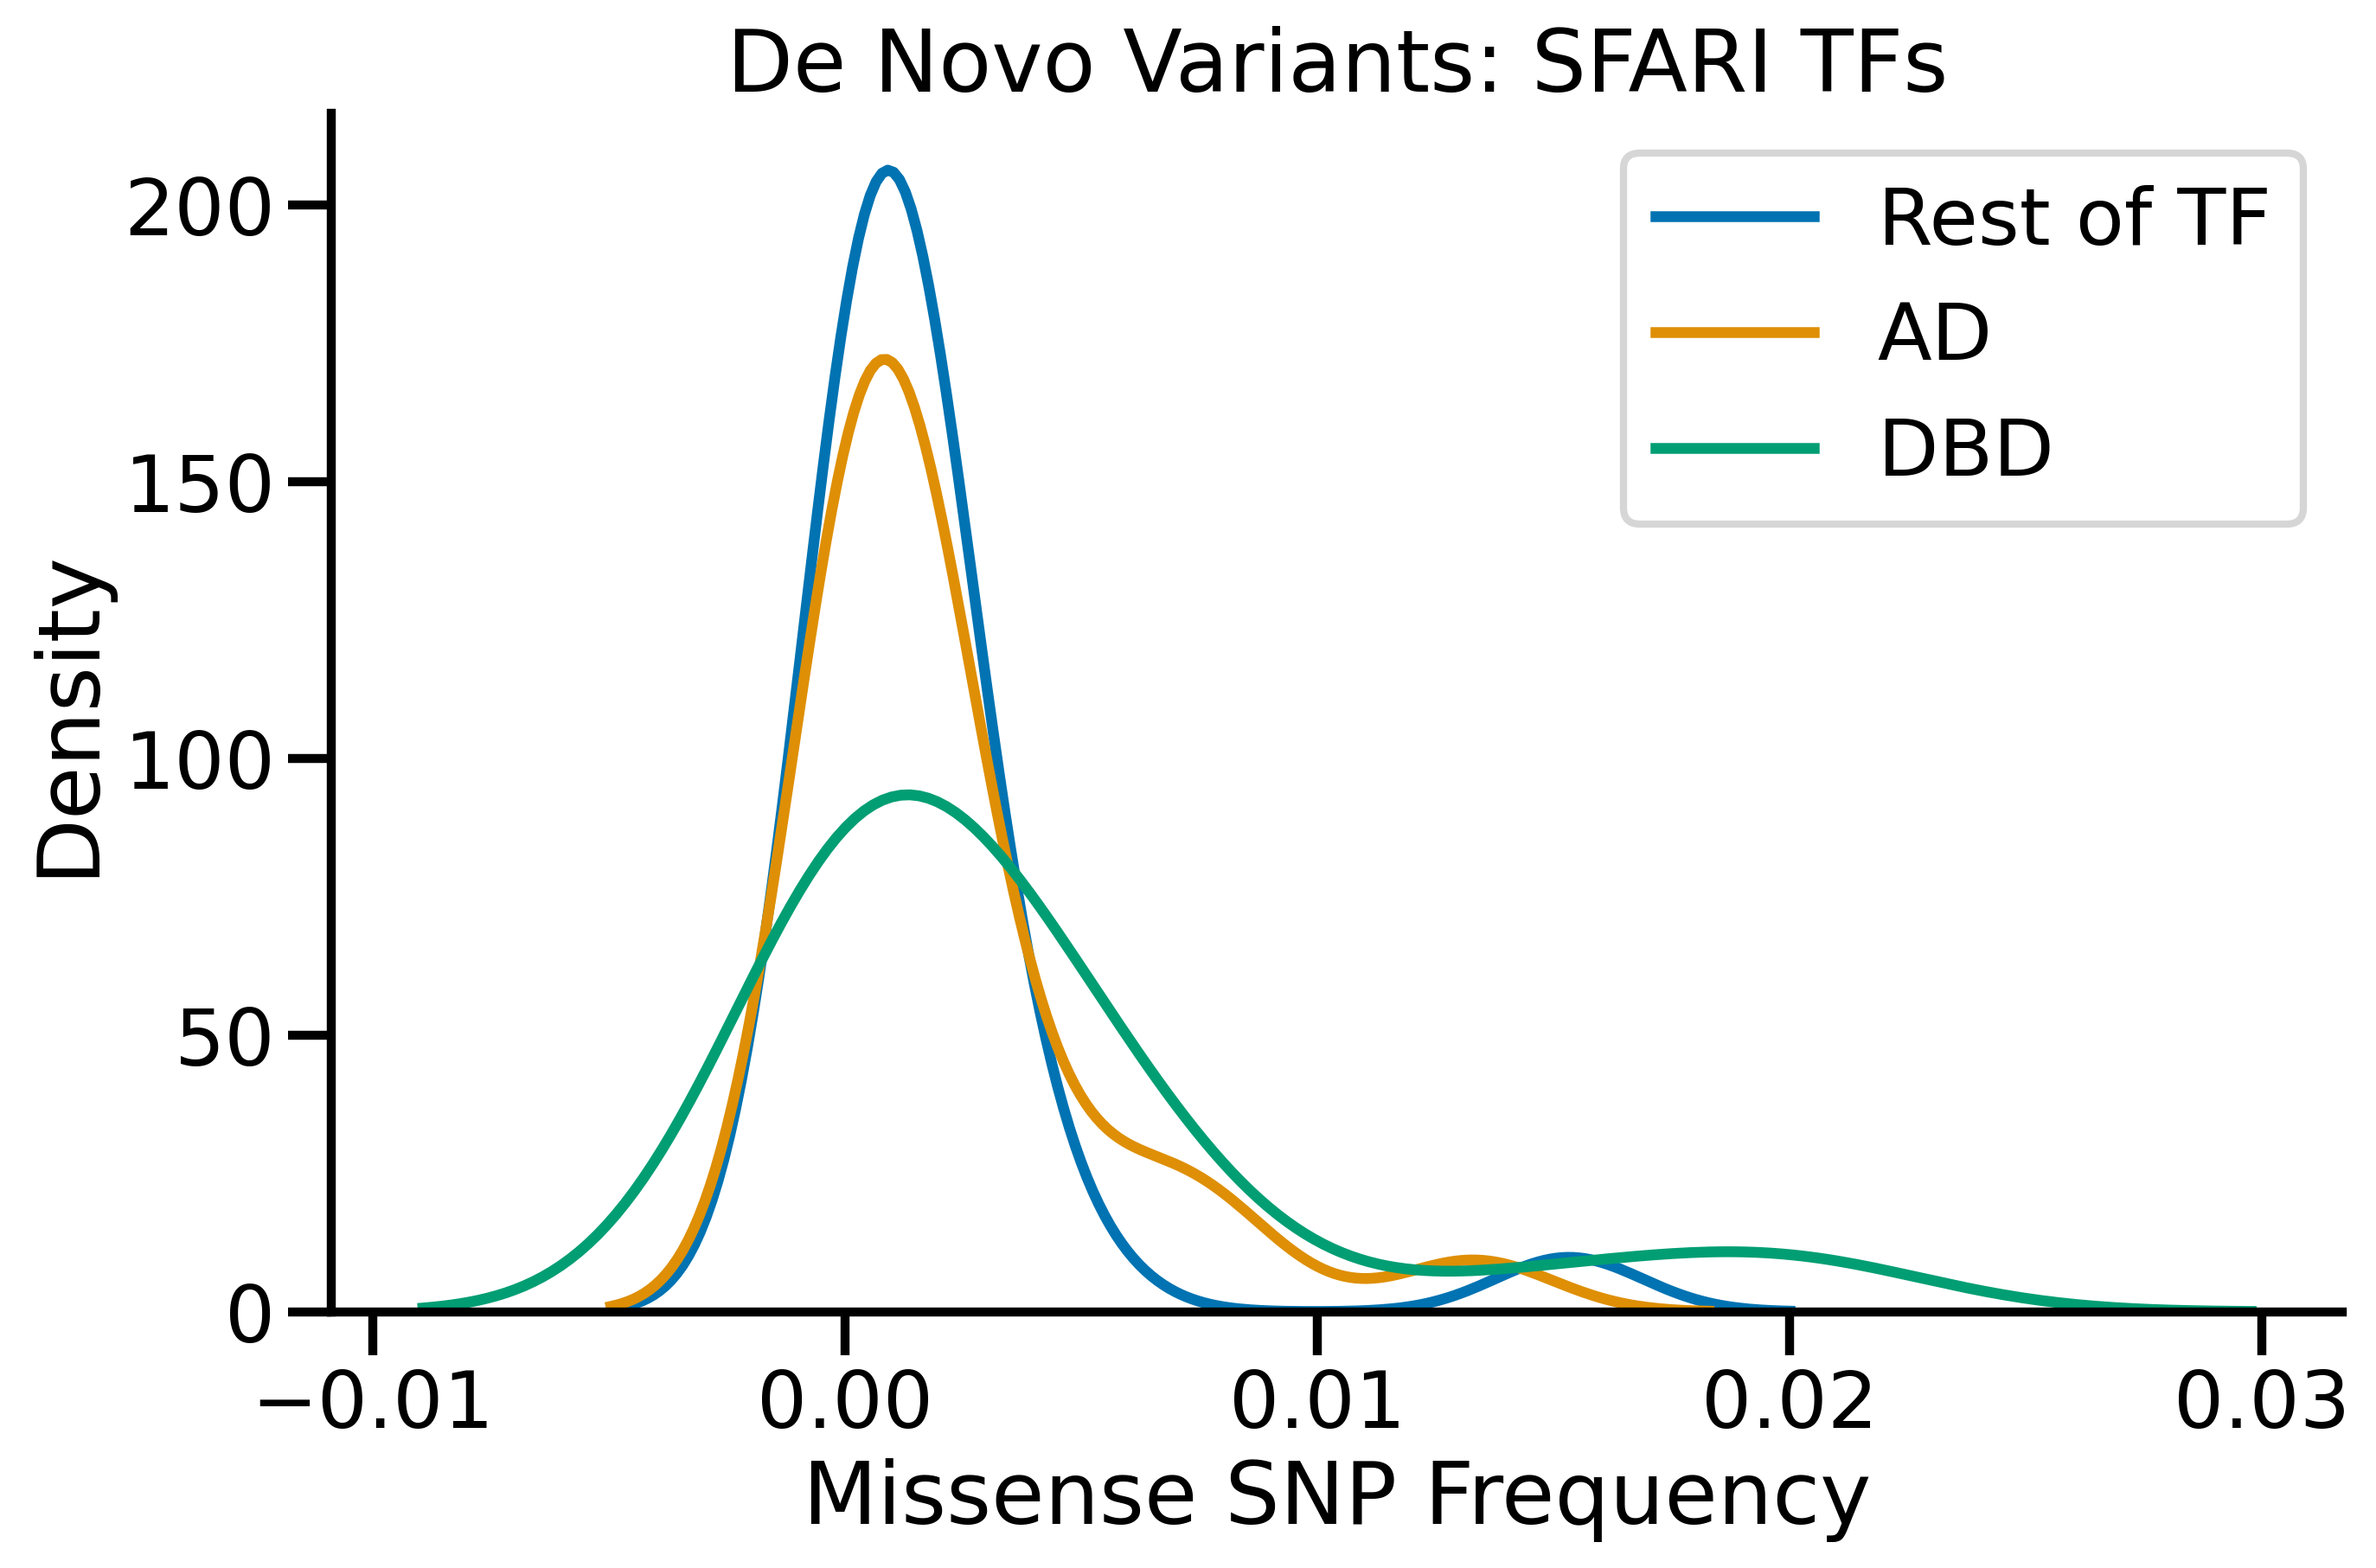

In [151]:
palette = sns.color_palette('colorblind')
sns.set_context('poster')
plt.figure(figsize = (10, 6), dpi = 300)


rest_of_TF_prop = (output["TF_missense"] - output["AD_missense"]) \
/ (output["TF_cds_length"] - output["AD_cds_length"])

sns.kdeplot(rest_of_TF_prop, label = "Rest of TF", color = palette[0]);
sns.kdeplot(output["AD_missense_prop"], color = palette[1], label = "AD");
sns.kdeplot(output["DBD_missense_prop"], color = palette[2], label = "DBD");


plt.legend()
plt.xlabel("Missense SNP Frequency")
plt.title("De Novo Variants: SFARI TFs")
sns.despine()

In [115]:
for gene in set(contains_DBD_sig["gene-symbol"]) | set(sig_output["gene-symbol"]):
    print(gene)

In [ ]:
len(set(contains_DBD_sig["gene-symbol"]) or set(sig_output["gene-symbol"]))

24

In [ ]:
hit_genes = [
    "TFE3", "CASZ1", "CAMTA2", "ARNT2", "YY1", "ERG", "PAX5", "MEIS2", "ESR2",
    "NR1D1", "OTX1", "PITX1", "RORA", "HIVEP3", "NKX2-2", "PAX6", "KLF7",
    "NR4A2", "AR", "KDM5B", "GLIS1", "ARX", "TCF7L2", "EGR3", "MYT1L",
    "MTF1", "IKZF1", "KLF16"
]


In [ ]:
known_ADs = pd.read_csv("../../output/known_ADs_considering_isoforms_and_canonical.csv")
hit_gene_ADs = known_ADs[known_ADs["Gene"].isin(hit_genes)]
hit_gene_ADs = hit_gene_ADs[~hit_gene_ADs["uniprotID"].str.contains("-")]
hit_gene_ADs["AD Length"] = hit_gene_ADs["ProteinRegionSeq"].str.len()
hit_gene_ADs[["Gene", "AD Length"]].groupby("Gene")["AD Length"].apply(list).reset_index()

,Gene,AD Length
0,AR,"[494, 259]"
1,ARNT2,[194]
2,ARX,[91]
3,CAMTA2,"[184, 110]"
4,CASZ1,[155]
5,EGR3,[202]
6,ERG,"[47, 144]"
7,ESR2,"[148, 197]"
8,GLIS1,[174]
9,HIVEP3,[864]
